<a href="https://colab.research.google.com/github/julia-zhmurko/JuliaZhmurko-ML/blob/main/%D0%9B%D0%B0%D0%B1%D0%BE%D1%80%D0%B0%D1%82%D0%BE%D1%80%D0%BD%D1%96_%D1%80%D0%BE%D0%B1%D0%BE%D1%82%D0%B8/%D0%96%D0%BC%D1%83%D1%80%D0%BA%D0%BE_%D0%AE%D0%BB%D1%96%D1%8F_%D0%A4%D0%86%D0%A2_4_10_%D0%9B%D0%91_2_%D0%9C%D0%9D_%D0%97%D0%B0%D0%B2%D0%B4%D0%B0%D0%BD%D0%BD%D1%8F_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Автор:** студентка групи ФІТ 4-10 Жмурко Юлія Андріївна

**Була присутня на парі (16.09.2026)**

In [25]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Завантажити датасет Titanic з Kaggle (або використовувати вже завантажений файл titanic.csv)

Посилання на датасет titanic.csv з Kaggle:

https://www.kaggle.com/datasets/mahmoudshogaa/titanic-dataset

1. Вивести перші 5 рядків датасету.

In [26]:
import kagglehub
import os

path = kagglehub.dataset_download("mahmoudshogaa/titanic-dataset")
print("Шлях до файлів датасету:", path)

Using Colab cache for faster access to the 'titanic-dataset' dataset.
Шлях до файлів датасету: /kaggle/input/titanic-dataset


In [27]:
df = pd.read_csv(os.path.join(path, "titanic.csv"))
print("Виведення перших 5 рядків датасету titanic.csv:")
df.head()

Виведення перших 5 рядків датасету titanic.csv:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


**PassengerId:** Унікальний ідентифікатор для кожного пасажира.

**Survived:** У цьому стовпці вказується, чи вижив пасажир (1), чи ні (0).

**Pclass** (Клас квитка): Показник соціально-економічного статусу, де 1 – найвищий клас, а 3 – найнижчий.

**Name:** Ім'я пасажира.

**Sex:** Стать пасажира.

**Age:** Вік пасажира. (Примітка: У цьому стовпці можуть бути відсутні значення.)

**SibSp:** Кількість братів і сестер або подружжя пасажира на борту «Титаніка».

**Parch:** Кількість батьків або дітей пасажира на борту «Титаніка».

**Ticket:** Номер квитка.

**Fare:** Сума грошей, яку пасажир сплатив за квиток.

**Cabin:** Номер каюти.

**Embarked:** Порт посадки на борт (C = Шербур, Q = Квінстаун, S = Саутгемптон).

2. Визначити розмір датасета.
3. Визначити тип даних.

In [28]:
#2
print("Розмір датасету (рядки, стовпці):", df.shape)

#3
print("\nТипи даних для кожного стовпця:")
print(df.dtypes)

print("\nЗагальна інформація про датасет (типи даних, кількість заповнених значень та пам'ять):")
df.info()

Розмір датасету (рядки, стовпці): (891, 12)

Типи даних для кожного стовпця:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Загальна інформація про датасет (типи даних, кількість заповнених значень та пам'ять):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       89

4. Визначити наявність пропущених значень. При наявності, замінити пропущенні значення на медіану.

In [29]:
print("Кількість пропущених значень до обробки:")
df.isnull().sum()

Кількість пропущених значень до обробки:


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [30]:
# Заміна пропусків медіаною для числового стовпця віку
df['Age'] = df['Age'].fillna(df['Age'].median(skipna = True))

# Видалення категоріальних стовпців із пропусками (оскільки для них медіана не обчислюється)
df.drop(['Cabin'], axis = 1, inplace = True)
df.drop(['Embarked'], axis = 1, inplace = True)

5. Ще раз перевірити наявність пропущених значень.

In [31]:
print("\nПропуски після обробки:")
df.isnull().sum()


Пропуски після обробки:


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


6. Сформувати датасет з обраними стовпцями ['Survived', 'Pclass', 'Sex', 'Age', 'Fare']

In [32]:
df = df[['Survived', 'Pclass', 'Sex', 'Age', 'Fare']]

print("Перші 5 рядків сформованого датасету:")
df.head()

Перші 5 рядків сформованого датасету:


,Survived,Pclass,Sex,Age,Fare
0,0,3,male,22.0,7.2500
1,1,1,female,38.0,71.2833
2,1,3,female,26.0,7.9250
3,1,1,female,35.0,53.1000
4,0,3,male,35.0,8.0500


7. Замінити бінарні ознаки (Стать) на 0 і 1 (перевірити унікальні значення даного стовпчика).

In [33]:
print("Кількість пасажирів за статтю:")
df['Sex'].value_counts()

Кількість пасажирів за статтю:


,count
Sex,
male,577
female,314


In [34]:
print("Унікальні значення стовпця Sex до заміни:", df['Sex'].unique())

df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

print("Унікальні значення стовпця Sex після заміни:", df['Sex'].unique())

print("\nТип даних датасету після заміни:")
print(df.dtypes)

Унікальні значення стовпця Sex до заміни: ['male' 'female']
Унікальні значення стовпця Sex після заміни: [0 1]

Тип даних датасету після заміни:
Survived      int64
Pclass        int64
Sex           int64
Age         float64
Fare        float64
dtype: object


8. Вивести описову статистику датасету describe().

In [35]:
print("Описова статистика для числових ознак датасету:")
df.describe()

Описова статистика для числових ознак датасету:


,Survived,Pclass,Sex,Age,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,0.352413,29.361582,32.204208
std,0.486592,0.836071,0.477990,13.019697,49.693429
min,0.000000,1.000000,0.000000,0.420000,0.000000
25%,0.000000,2.000000,0.000000,22.000000,7.910400
50%,0.000000,3.000000,0.000000,28.000000,14.454200
75%,1.000000,3.000000,1.000000,35.000000,31.000000
max,1.000000,3.000000,1.000000,80.000000,512.329200


9. Ще раз перевірити кількість пропущених даних (впевнитись, що їх немає).

In [36]:
print("Перевірка кількості пропущених даних у кожному стовпці:")
df.isnull().sum()

Перевірка кількості пропущених даних у кожному стовпці:


,0
Survived,0
Pclass,0
Sex,0
Age,0
Fare,0


10. Вивести 5 перших рядків датасету.

In [37]:
print("Перші 5 рядків датасету:")
df.head()

Перші 5 рядків датасету:


,Survived,Pclass,Sex,Age,Fare
0,0,3,0,22.0,7.2500
1,1,1,1,38.0,71.2833
2,1,3,1,26.0,7.9250
3,1,1,1,35.0,53.1000
4,0,3,0,35.0,8.0500


11. Вивести 5 останніх рядків датасету.

In [38]:
print("Останні 5 рядків датасету:")
df.tail()

Останні 5 рядків датасету:


,Survived,Pclass,Sex,Age,Fare
886,0,2,0,27.0,13.00
887,1,1,1,19.0,30.00
888,0,3,1,28.0,23.45
889,1,1,0,26.0,30.00
890,0,3,0,32.0,7.75


12. Аналіз виживання залежно від статі: Обчисліть відсоток виживання для кожної статі. Чи була різниця у виживанні між чоловіками та жінками?

In [39]:
survival_by_sex = df.groupby('Sex')['Survived'].mean() * 100

print("Відсоток виживання за статтю (%):")
print(survival_by_sex.map('{:.2f}%'.format))

print(f"\nЧоловіки (0): {survival_by_sex[0]:.2f}%")
print(f"Жінки (1): {survival_by_sex[1]:.2f}%")

correlation = df['Sex'].corr(df['Survived'])
print(f"\nКоефіцієнт кореляції між статтю та виживанням: {correlation}")

Відсоток виживання за статтю (%):
Sex
0    18.89%
1    74.20%
Name: Survived, dtype: object

Чоловіки (0): 18.89%
Жінки (1): 74.20%

Коефіцієнт кореляції між статтю та виживанням: 0.5433513806577555


**Різниця у виживанні між чоловіками та жінками була величезною**:

* **Жінки (1): вижили приблизно 74.20%.**

* **Чоловіки (0): вижили лише близько 18.89%.**

**Різниця становить понад 55% на користь жінок, що пояснюється дією правила евакуації «спочатку жінки та діти».**

13. Обчисліть відсоток виживання для кожного класу (Pclass). Який клас мав найвищий рівень виживання (дати відповідь)?

In [40]:
survival_by_pclass = df.groupby('Pclass')['Survived'].mean() * 100

print("Відсоток виживання за класом (%):")
print(survival_by_pclass.map('{:.2f}%'.format))

for pclass, percentage in survival_by_pclass.items():
    print(f"Клас {pclass}: {percentage:.2f}%")

Відсоток виживання за класом (%):
Pclass
1    62.96%
2    47.28%
3    24.24%
Name: Survived, dtype: object
Клас 1: 62.96%
Клас 2: 47.28%
Клас 3: 24.24%


**Найвищий рівень виживання мав 1-й клас (62.96%).**

**Спостерігається чітка залежність між класом квитка та шансами вижити, оскільки:**
* **1-й клас: вижили близько 62.96% пасажирів.**
* **2-й клас: вижили близько 47.28% пасажирів.**
* **3-й клас: вижили лише 24.24% пасажирів.**

**Це пояснюється тим, що каюти 1-го класу розташовувалися на верхніх палубах ближче до рятувальних шлюпок, а також пріоритетом під час евакуації.**

14. Визначте середній вік тих, хто вижив, і тих, хто не вижив. Чи впливає вік на виживання (дати відповідь)?

In [41]:
age_survival = df.groupby('Survived')['Age'].mean()

print("Середній вік пасажирів за статусом виживання:")
print(f"Загинули (0): {age_survival[0]:.2f} років")
print(f"Вижили (1):   {age_survival[1]:.2f} років")

Середній вік пасажирів за статусом виживання:
Загинули (0): 30.03 років
Вижили (1):   28.29 років


**Середній вік тих, хто вижив, становить 28.29 року, а тих, хто загинув — 30.03 року.**

**Сам по собі середній вік практично не відрізняється між двома групами, проте загалом вік впливав на виживання у крайніх категоріях (діти мали перевагу).**

15. Розподіліть пасажирів на групи за рівнями тарифів (Fare) і обчисліть рівень виживання для кожної групи. Як тариф впливав на шанси виживання (дати відповідь)?

In [42]:
# Розподіл на 6 категорій
df['Fare_Category'] = pd.qcut(df['Fare'], q = 6, labels = False)

# Обчислення відсотка виживання для кожної групи
surv_rate = df.groupby('Fare_Category')['Survived'].mean() * 100

for i, rate in surv_rate.items():
    print(f'Група {i}: {rate:.2f}%')

Група 0: 20.51%
Група 1: 19.08%
Група 2: 36.69%
Група 3: 43.62%
Група 4: 41.78%
Група 5: 69.80%


**Що вищою є категорія тарифу (Fare_Category), то вищі шанси на виживання мали пасажири.**

* **У найдешевшій категорії (Група 0) відсоток виживання є найнижчим.**
* **У найдорожчій категорії (Група 5) відсоток виживання є найвищим.**

**Це пояснюється тим, що пасажири з дорожчими квитками розміщувалися на вищих палубах і мали пріоритет під час евакуації.**

16. Аналіз класу та тарифу: Визначте середній тариф (Fare) для кожного класу (Pclass). Чи існує значна різниця у тарифах між класами (дати відповідь)?

In [43]:
# 16.1 Обчислення середнього тарифу для кожного класу
fare_by_class = df.groupby('Pclass')['Fare'].mean()

print("Середній тариф (Fare) за класами (Pclass):")
for pclass, mean_fare in fare_by_class.items():
    print(f"Клас {pclass}: {mean_fare:.2f}")

Середній тариф (Fare) за класами (Pclass):
Клас 1: 84.15
Клас 2: 20.66
Клас 3: 13.68


**Існує величезна та значна різниця у тарифах між класами пасажирів, особливо між 1-м класом та іншими двома.**

**Середня вартість квитка для 1-го класу (84.15) є більш ніж у 4 рази вищою, ніж для 2-го класу (20.66).**

**Різниця між 2-м класом (20.66) та 3-м класом (13.68) є меншою, але квиток 2-го класу все одно дорожчий приблизно на 50%.**

17. Обчисліть середній вік пасажирів для кожного класу (Pclass). Як вік пасажирів розподіляється за класами (дати відповідь)?

Середній вік за класами:
Pclass
1    36.812130
2    29.765380
3    25.932627
Name: Age, dtype: float64


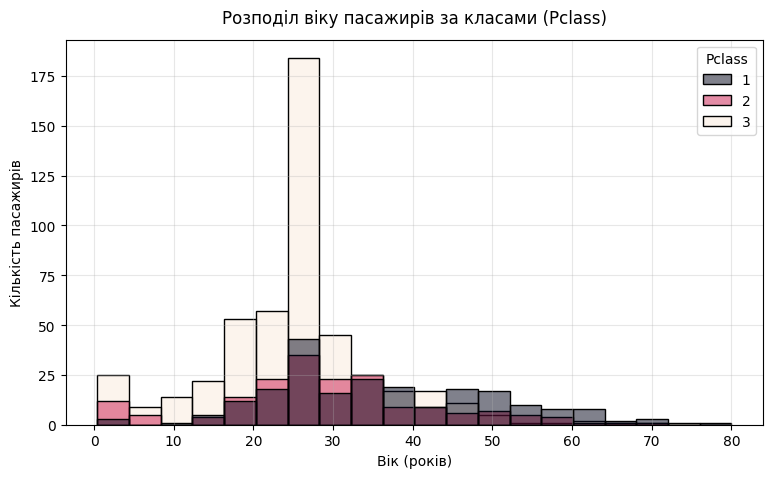

In [44]:
mean_age = df.groupby('Pclass')['Age'].mean()
print("Середній вік за класами:")
print(mean_age)

plt.figure(figsize = (9, 5))
sns.histplot(data = df, x = 'Age', hue = 'Pclass', bins = 20, palette = 'rocket')

plt.title('Розподіл віку пасажирів за класами (Pclass)', fontsize = 12, pad = 12)
plt.xlabel('Вік (років)', fontsize = 10)
plt.ylabel('Кількість пасажирів', fontsize = 10)
plt.grid(alpha = 0.3)
plt.show()

**Відповідно до побудованої гістограми, спостерігається чітка тенденція — що вищий клас квитка, то вишим є середній вік пасажирів.**

* **1-й клас: Переважають люди середнього та старшого віку (30–80 років), що пояснюється високою вартістю квитків.**
* **2-й клас: Охоплює переважно молодь та людей середнього віку (20–40 років).**
* **3-й клас: Наймолодша група з вираженим піком у районі 20–30 років (молоді робітники та іммігранти), а також помітною кількістю дітей.**

**У 3-му класі спостерігається величезна концентрація пасажирів (понад 130 осіб в одному інтервалі). Це пояснюється тим, що 3-м класом подорожували переважно молоді робітники та іммігранти, а також тим, що при заповненні пропущених значень у датасеті Titanic (Age) часто підставляли саме медіанне/середнє значення (~28 років).**

**Найбільша кількість дітей спостерігається у 3-му та 2-му класах (подорожували сім'ями), тоді як у 1-му класі пасажирів віком до 15 років майже немає.**

In [45]:
# Розрахунок відсотку виживання для кожного класу та для кожної статі
for i in range(1, 4):
    for j in [0, 1]:
        group = df[(df['Pclass'] == i) & (df['Sex'] == j)]

        if len(group) > 0:
            surv_rate = (group['Survived'] == 1).sum() / len(group)
            gender_label = "Male" if j == 0 else "Female"
            print(f'{gender_label:<7}passengers in class {i}: {surv_rate * 100:.2f}%')

Male   passengers in class 1: 36.89%
Female passengers in class 1: 96.81%
Male   passengers in class 2: 15.74%
Female passengers in class 2: 92.11%
Male   passengers in class 3: 13.54%
Female passengers in class 3: 50.00%


**Жінки мали значно вищі шанси на виживання у порівнянні з чоловіками в усіх трьох класах завдяки евакуаційній політиці «спочатку жінки та діти».**

**Вплив класу (соціально-економічний фактор):**

* **1-й клас: Найвищий рівень виживання для обох статей. Майже всі жінки (96.81%) вижили, а серед чоловіків вижила третина (36.89%).**

* **2-й клас: Жінки зберегли високий відсоток виживання (92.11%), у той час як відсоток виживших чоловіків різко впав до 15.74%.**

* **3-й клас: Найнижчі шанси. Навіть серед жінок вижила лише половина (50.00%), а серед чоловіків — лише 13.54% (найнижчий показник серед усіх груп).**

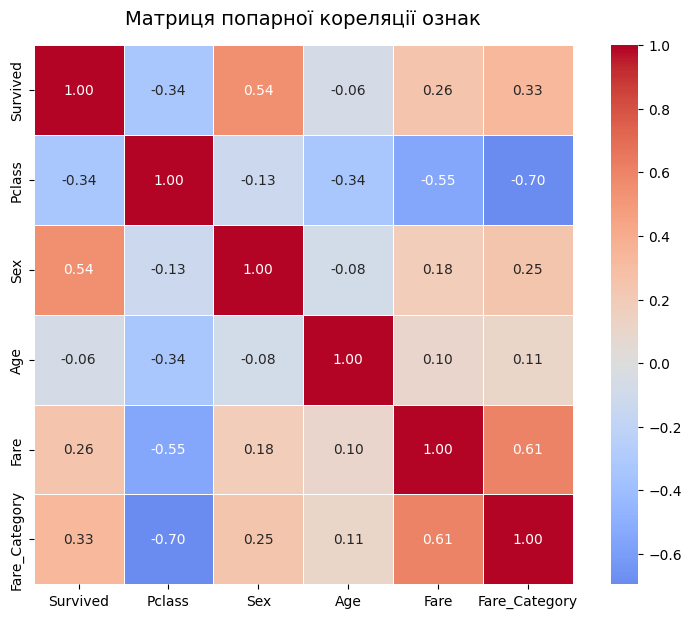

In [46]:
# Відбір лише числових стовпчиків та виключення службового PassengerId
numeric_df = df.select_dtypes(include = ['number']).drop(columns = ['PassengerId'], errors = 'ignore')

# Обчислення матриці кореляції Пірсона
corr_matrix = numeric_df.corr()

plt.figure(figsize = (10, 7))
sns.heatmap(
    corr_matrix,
    annot = True,
    fmt = '.2f',
    cmap = 'coolwarm',
    center = 0,
    linewidths = 0.5,
    square = True
)

plt.title('Матриця попарної кореляції ознак', fontsize = 14, pad = 15)
plt.show()

**Висновок до теплової карти кореляції ознак:**

* **Sex (0.54): Найсильніший позитивний зв'язок із виживанням. Це підтверджує, що жіноча стать була визначальним фактором для порятунку.**

* **Pclass (-0.34): Помірна від'ємна кореляція. Що менший номер класу (1-й клас), то вищі шанси вижити.**

* **Fare (0.26) та Fare_Category (0.33): Позитивна кореляція — пасажири з дорожчими квитками мали вищий відсоток виживання.**

* **Pclass та Fare_Category (-0.70) / Fare (-0.55): Сильний від'ємний зв'язок. 1-й клас квитка логічно відповідає найбільшій вартості та найвищій ціновій категорії.**

* **Fare та Fare_Category (0.61): Закономірна сильна позитивна кореляція, оскільки категорія тарифу прямо похідна від вартості квитка.**

* **Pclass та Age (-0.34): Старші пасажири частіше подорожували 1-м класом, тоді як молодь частіше перебувала у 3-му класі.**